# Hola! 😀

Soy **Jaime Paz** y mis amigos me suelen llamar James! – *"Tranquilo, no juego en el Real Madrid"* ⚽😅. Sí, como el futbolista James Rodríguez, pero en versión científico de datos… y mejor no me digas como a él. 😉

Como tu revisor en TripleTen, estoy aquí para ayudarte a pulir tu código y tu forma de trabajar con datos. Si algo necesita un ajuste, no te preocupes: la idea es que cada comentario te acerque más a cómo se trabaja en un entorno profesional y que tu proyecto brille con todo su potencial.

Cada vez que encuentre un detalle importante en tu notebook, te lo señalaré para que puedas corregirlo y seguir creciendo. Si en algún punto no logras resolver algo, también estoy para guiarte en próximos intentos de revisión. 🔁

Es muy importante que, cuando veas mis comentarios en el notebook, **no los muevas, no los modifiques y no los borres**. Así mantenemos un historial claro de lo que ya revisamos y de tus avances. ✅

---

### Formato de Comentarios

Revisaré cuidadosamente tu notebook para asegurar que cumpla con los requisitos y te daré comentarios usando el siguiente formato:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Éxito</b> ✅ - ¡Excelente trabajo! Esta parte está bien implementada y contribuye de forma positiva al análisis o al proyecto. Sigue aplicando estas buenas prácticas en las siguientes secciones.
    
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Atención</b> ⚠️ - Esta parte del código funciona, pero se puede mejorar u optimizar. Tal vez sea más claro, más eficiente o más fácil de mantener. Te señalaré ideas para que puedas reforzar esta sección.
    
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>A resolver</b> ❗ - Aquí hay un problema o error que es necesario corregir para aprobar esta parte. Revisa el comentario con calma, ajústalo y vuelve a intentarlo; es clave para la validez del análisis y la precisión de los resultados.
    
</div>

---

Al final de cada revisión, recibirás un **Comentario General del Revisor** que incluirá:

- **Aspectos positivos:** Un resumen de los puntos fuertes de tu proyecto. 💪
- **Áreas de mejora:** Sugerencias claras sobre lo que puedes reforzar. 💡
- **Temas adicionales para investigar:** Ideas opcionales que puedes explorar por tu cuenta para seguir creciendo.

Estos temas adicionales no son obligatorios ahora, pero pueden ayudarte a profundizar en el futuro. 📚

---

Si tienes dudas o quieres responder a un comentario específico, puedes usar este formato:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>
    
Aquí puedes escribir tu respuesta o pregunta sobre el comentario.
    
</div>

**¡Empecemos!** 🚀

<div class="alert alert-block alert-success">

<b>Comentario del revisor</b> <a class="tocSkip"></a><br>

    

<b>Éxito</b> ✅ - ¡Excelente trabajo Iris! Tu proyecto es excepcional y has logrado cubrir los objetivos del mismo. Ahora has adjuntado correctamente la presentacion (google drive) de tu proyecto, por lo que los items quedan cubiertos. 

¡Felicidades en completar el Bootcamp!!!!!!  🥇🥇🥇   

</div>



<div class="alert alert-block alert-danger">

<b>Comentario del revisor</b> <a class="tocSkip"></a><br>

<b>A resolver!</b> ❗ - ¡Hola Iris! Veo que has avanzado en la fase de normalización y protecciones al Z test (aunque con unas recomendaciones que detallo en la siguiente celda).

Ahora bien, respecto al link de tu presentación final, no he podido encontrarla. ¿Has podido revisar los tutoriales que te he brindado para brindar el link correctamente? Recuerda que esperamos que el link final que proporciones tenga este aspecto:

https://drive.google.com/drive/folders/1y1I9S_omQFDX6M1N4peIEEbCRj2AZJ0q?usp=sharing

- https en direccion URL

- Que dirija a drive.google.com (no precisamente a tu PC)

- Si tienes problemas en generar el link correcto, puedes agregar tu archivo PDF en este mismo espacio (es decir, arrastra tu archivo PDF a la siguiente sección de tu pagina ):

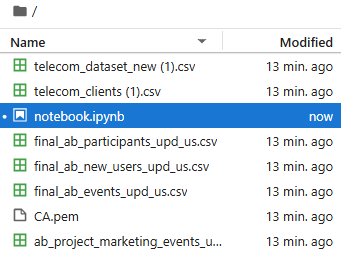
</div>



<div class="alert alert-block alert-info">
<b>Respuesta del revisor</b> <a class="tocSkip"></a><br>
hola Iris! Has avanzado en tu entregable: ya normalizaste "internal" (celdas 20-21) y añadiste protecciones al Z-test (celdas 52-54). 
    
Ahora, lo que podemos mejorar es recomputar el funnel asegurando que los eventos faltantes por grupo queden con valor 0 (evita NaNs en el Z-test) y proteger el t-test contra muestras pequeñas/varianza cero (ahora se ejecutó sin guard). Abajo te dejo un snippet final que nos puede ayudar a resolver este problema. Solo si es necesario, ajusta nombres si tu dataframe difiere , que normaliza internals, recompone el funnel con ceros, corre Z-tests robustos y aplica guard al t-test. 🚀💡


```python
# 1) Normalizar internal de forma consistente
telecom['internal_clean'] = (
    telecom['internal'].astype(str).str.strip().str.lower()
    .map({'t':1,'true':1,'1':1,'yes':1,'y':1,
          'f':0,'false':0,'0':0,'no':0,'n':0})
    .fillna(0).astype(int)
)

# 2) Recomputar el funnel asegurando ceros para combinaciones faltantes
funnel_events = ['product_page','product_card','purchase']
f = (events[events['event_name'].isin(funnel_events)]
     .groupby(['group','event_name'])['user_id']
     .nunique().unstack(fill_value=0)
)
f = f.reindex(columns=funnel_events, fill_value=0)

# Asegurar índices para A y B (si falta alguno)
for g in ['A','B']:
    if g not in f.index:
        f.loc[g] = 0
f = f.sort_index()

# total users por grupo (usuarios dentro del experimento)
total_users = users_ab.groupby('group')['user_id'].nunique().to_dict()

# conversiones por grupo/etapa
conv = f.div(pd.Series(total_users), axis=0).fillna(0)

# 3) Z-test robusto
import numpy as np
from scipy.stats import norm
def z_test(success_a, size_a, success_b, size_b):
    if size_a == 0 or size_b == 0:
        return np.nan, np.nan
    p1, p2 = success_a/size_a, success_b/size_b
    p_pool = (success_a + success_b) / (size_a + size_b)
    if p_pool == 0 or p_pool == 1:
        return np.nan, np.nan
    se = np.sqrt(p_pool * (1 - p_pool) * (1/size_a + 1/size_b))
    if se == 0:
        return np.nan, np.nan
    z = (p1 - p2) / se
    pval = 2 * (1 - norm.cdf(abs(z)))
    return z, pval

results = []
for evt in funnel_events:
    a = int(f.loc['A', evt]) if 'A' in f.index else 0
    b = int(f.loc['B', evt]) if 'B' in f.index else 0
    n_a = int(total_users.get('A', 0))
    n_b = int(total_users.get('B', 0))
    z, p = z_test(a, n_a, b, n_b)
    results.append({'event':evt, 'succ_A':a, 'succ_B':b, 'n_A':n_a, 'n_B':n_b, 'z':z, 'p':p})

ab_results = pd.DataFrame(results)
print(ab_results)

# 4) t-test con guardias para muestras pequeñas/varianza cero
from scipy.stats import ttest_ind
ineff = operator_metrics[operator_metrics['inefficient']]['avg_wait_time'].dropna()
eff = operator_metrics[~operator_metrics['inefficient']]['avg_wait_time'].dropna()

if len(ineff) < 2 or len(eff) < 2 or (ineff.var() == 0 and eff.var() == 0):
    print("No se puede correr t-test: muestras insuficientes o varianza cero")
else:
    print(ttest_ind(ineff, eff, equal_var=False))
```
</div>

<div class="alert alert-block alert-danger">

<b>Comentario del revisor</b> <a class="tocSkip"></a><br>

<b>A resolver!</b> ❗ - Hola Iris! Veo que has avanzado con nuestros pendientes; sin embargo, nos queda área de oportunidad para cerrarlos correctamente.

En los siguientes 3 bloques te adjunto las nuevas observaciones. En total, tenemos aún **2 puntos pendientes.**

¡Espero pronto tus respuestas!    

</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor V</b> <a class="tocSkip"></a><br>

Hola Iris! Veo que has avanzado con nuestros pendientes, aunque no todos los puntos prioritarios quedaron resueltos ✅/⚠️.  

**PUNTO PENDIENTE 1 (CORREGIR UNOS ERRORES DE LA IMPLEMENTACION)**

- El problema de product_card (conteos 0 → NaN en Z-test) aparece todavía en el resultado del funnel; y
- la columna internal tuvo varios intentos (hay inconsistencias entre celdas).
- Además el t-test devolvió NaN porque una de las muestras está vacía o con varianza 0.

Para ayudarte, aquí tienes un snippet de codigo para: 

1) normalizar internal de forma consistente;
  
2) recomputar el funnel incluyendo eventos con cero; y

3) ejecutar pruebas Z/T con protecciones para evitar NaN. 🚀💡

```python
# 1) primero, normalizamos 'internal' de forma consistente
telecom['internal_clean'] = (
    telecom['internal']
    .astype(str).str.strip().str.lower()
    .map({'t':True,'true':True,'1':True,'yes':True,'y':True,
          'f':False,'false':False,'0':False,'no':False,'n':False})
    .fillna(False).astype(bool)
)
print(telecom['internal_clean'].value_counts())

# 2) "Recomputamos" funnel asegurando columnas para todos los eventos
funnel_events = ['product_page','product_card','purchase']
f = (events[events['event_name'].isin(funnel_events)]
     .groupby(['group','event_name'])['user_id']
     .nunique().unstack(fill_value=0)
)

# aseguramos columnas y grupos A/B presentes
f = f.reindex(columns=funnel_events, fill_value=0)
total_users = users_ab.groupby('group')['user_id'].nunique()
conv = f.div(total_users, axis=0)
print(conv)

# 3) Aqui viene el Z-test, el cual ya es mas robusto y ejecución con checks (es decir,  evita divisiones por cero / p_pool extremos)

import numpy as np
from scipy import stats
def z_test(success_a, size_a, success_b, size_b):
    if size_a==0 or size_b==0:
        return np.nan, np.nan
    p1, p2 = success_a/size_a, success_b/size_b
    p_pool = (success_a + success_b) / (size_a + size_b)
    if p_pool in (0,1):
        return np.nan, np.nan
    se = np.sqrt(p_pool*(1-p_pool)*(1/size_a + 1/size_b))
    z = (p1 - p2) / se
    pvalue = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, pvalue

results = []
for evt in funnel_events:
    a = int(f.loc['A', evt]) if 'A' in f.index else 0
    b = int(f.loc['B', evt]) if 'B' in f.index else 0
    size_a = int(total_users.get('A', 0))
    size_b = int(total_users.get('B', 0))
    z, p = z_test(a, size_a, b, size_b)
    results.append((evt, a, b, size_a, size_b, z, p))

import pandas as pd

pd.DataFrame(results, columns=['event','succ_A','succ_B','n_A','n_B','z','p'])

# 4) t-test guard (para operator_metrics avg_wait_time)

from scipy.stats import ttest_ind
ineff = operator_metrics[operator_metrics['inefficient']]['avg_wait_time'].dropna()
eff = operator_metrics[~operator_metrics['inefficient']]['avg_wait_time'].dropna()
if len(ineff) < 2 or len(eff) < 2 or (ineff.var()==0 and eff.var()==0):
    print("No se puede correr t-test: muestras insuficientes o varianza cero")
else:
    print(ttest_ind(ineff, eff, equal_var=False))
```

**Si deseas implementar este código que te he brindado de ayuda, solo debes confirmar que los nombres de tus columnas se adapten correctamente. Pero de la misma forma, puedes proponer un método que tú recomiendes. La idea es que no atrasemos mucho la entrega.**

</div>



<div class="alert alert-block alert-success">
<b>Comentario del revisor IV</b> <a class="tocSkip"></a><br>
    
<b>Éxito</b> ✅ - **PUNTO 2 (PRUEBA SQL):** Respecto a la prueba SQL, veo que ya la has completado. Damos por cerrado este punto. ✅
    
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor III</b> <a class="tocSkip"></a><br>

**PUNTO PENDIENTE 3 (link DRIVE):** El punto que nos persiste, es el link que proporcionaste de drive. Sin lugar a dudas, tu link funciona correctamente en tu máquina: file:///C:/Users/valen/OneDrive/Documentos/Presentacion_Proyectos_Analisis_Datos.pdf

El problema, es cuando debes distribuirlo al público; este link debe direccionarlos a una URL correcta, tal como la que te he adjuntado de ejemplo:  https://drive.google.com/drive/folders/1y1I9S_omQFDX6M1N4peIEEbCRj2AZJ0q?usp=sharing.

Si ves la diferencia, es que tu link debe tener correctamente las siglas "https://drive.google.com/" justo al inicio (actualmente tienes **file:///C:/Users/valen/**, que apuntan a tu máquina directamente).

Para ayudarte a cerrar este punto, te brindo un tutorial muy útil que he encontrado: 

**https://www.youtube.com/watch?v=RyTvc9N2O9A**

Una vez hayas corregido el punto No.1, te recomiendo actualizar tus documento final de acuerdo a los resultados que obtengas.

**Una vez completados el punto 1 y 3, damos por cerrado tu proyecto.**

</div>



**Conversaciones anteriores:**

<div class="alert alert-block alert-danger">

<b>Comentario del revisor</b> <a class="tocSkip"></a><br>

<b>A resolver!</b> ❗ - ¡Excelente trabajo! Tu proyecto es excepcional y has utilizado elementos avanzados para tu entrega. Es digno de admirar. Sin embargo, hay unos algunos detalles que deben completarse para dar por cerrado tu proyecto. Los segmentos marcados como **PRIORITARIO** son los que deben completarse para dar por cerrado tu proyecto. Los marcados como **RECOMENDADO** no son obligatorios, pero siempre es útil incluirlos en tu análisis. 

¡Espero pronto tus respuestas!    

</div>

<div class="alert alert-block alert-danger">

<b>Comentario del revisor II (actualizado) </b> <a class="tocSkip"></a><br>

<b>A resolver!</b> ❗ - ¡Hola Iris! Te comento que he revisado tus entregables, sin embargo, existen algunos pendientes respecto al contenido esperado. He actualizado los puntos, respecto al comentario anterior.


- **COMPLETO. 1. Proyecto de Pruebas A/B** El proyecto de pruebas A/B lo has completado: https://review.tripleten.com/projects/200226883/jupyter-project?secret=bf914621733145e2a72a2f414c858c3c

- **COMPLETO. 2.Proyecto de Descomposicion de Tareas** el proyecto de descomposición lo tienes ya aprobado: https://review.tripleten.com/projects/200225959/jupyter-project?secret=ab6d8f4388b64bf2a7034357c86be36f

- **COMPLETO. 3. Prueba SQL** Veo que ya se encuentra aprobada (al menos que la revisaste, quiza no se habia actualizdo): https://review.tripleten.com/projects/200226903/jupyter-project?secret=1142980717a54caca28054142ec3f54e

- **4. PENDIENTE: Presentación (diapositivas)**. Si bien has adjunto un link de Drive, asegurate que  la direccion url (https) sea la correcta y recuerda compartir tu link tipo "PUBLIC" en Google Drive. El URL que indicaste es un link directo a tu PC: file:///C:/Users/valen/OneDrive/Documentos/Presentacion_Proyectos_Analisis_Datos.pdf. Sin embargo, el link esperado debe ir algo como: https://drive.google.com/drive/folders/1y1I9S_omQFDX6M1N4peIEEbCRj2AZJ0q?usp=sharing . Es decir, debes subirlo a goole Drive y proporcionar una URL correcta.

- **5. PENDIENTE: Implementación del plan**. Si bien ya tienes una versión avanzada en el presente Jupyter Notebook aun nos falta corregir algunos inconvenientes (en la siguiente celda, encuentras los detalles). No olvides que el link que te he proporcionado, sigue siendo de ayuda para ayudarte a cerrar los pendientes: https://coding-bootcamps.notion.site/Instrucciones-espec-ficas-para-el-Caso-principal-2926ed1efc9381e19f10c54f06b5216e .  

Una vez completados los pasos 4 y 5, damos por cerrado tu proyecto.

¡Espero pronto tus resultados!

</div>





### Conclusiones y recomendaciones para el Proyecto de Implementación

- Nivel general: en conjunto, este trabajo se sitúa más en un nivel intermedio. Se nota buena intención técnica y análisis realizado, pero hay inconsistencias y algunos pasos clave faltantes ✅⚠️
- Puntos completados / no completados:
  - Completados: carga de datasets y conversiones básicas de fechas; unión de participantes/usuarios/events; filtrado temporal a 14 días; cálculo de agregados por operador; visualizaciones (histograma y series temporales); análisis del embudo y prueba Z para proporciones (implementada). ✅
  - **RECOMENDADO**: tratamiento de valores faltantes (el mapeo de la columna `internal` produjo pérdida de valores, conviene revisar la conversión de tipos);
  - **RECOMENDADO** definición y documentación de KPIs y umbrales (se usaron percentiles pero ha faltado justificarlos o bien, describirlos con como fórmulas);
  - **❗ PRIORITARIO** manejo de casos con cero eventos (product_card mostró 0 y generó NaN en pruebas). Al no contrarrestar el problema del manejo de casos con cero eventos, te produjo este problema. ⚠️❗ 
  - **RECOMENDADO** creación de funciones que automaticen procesos (no hay encapsulación en funciones/bucles);
  - **❗ PRIORITARIO** la prueba estadística la reportaste, pero tenemos problemas en la forma que la interpretas , lo cual se refleja en las conclusiones (ejemplo. t-test con NaN, y conclusiones que afirman significancia cuando hay NaN/valores contradictorios)❗ 

- Tus fortalezas claras:
  - Buen flujo general: datos cargados, fechas convertidas y unión lógica entre tablas (participants, users, events). ✅🚀
  - Visualizaciones útiles y pertinentes (distribución de wait_time, series diarias por grupo) que ayudan a detectar patrones temporales y diferencias entre grupos. 📈
  - Implementación de una función Z-test con protección ante p_pool extremos — muestra cuidado por condiciones numéricas. 💡

- Tus áreas prioritarias de mejora / a corregir:
  - **❗ PRIORITARIO, SIGUIENTE PASO** Corrige el manejo de la columna `internal` y valida NAs: la conversión actual introduce NaNs y afecta agregaciones por operador; revisa tipos antes de mapear y usa transformaciones consistentes. ❗
  - **RECOMENDADO** Define y documenta explícitamente los KPIs (fórmulas y umbrales) y justifica la elección de percentiles/umbrales; automatiza la identificación de "ineficaces" (por ejemplo, incluir criterio de llamadas salientes bajas). 🧾

  - **❗ PRIORITARIO, SIGUIENTE PASO** Arregla las inconsistencias en las pruebas estadísticas e interpreta resultados coherentemente: si una prueba devuelve NaN indaga por qué (muestras vacías) y te recomiendo evitar afirmar significancia cuando no hay evidencia.❗  🔁


- Observaciones sobre criterios técnicos importantes (suaves):
  - Toma en cuenta que faltó robustecer el tratamiento de nulos/tipos y documentar las decisiones de limpieza; esto impacta directamente en las pruebas e inferencias (incluso las conclusiones).
  - Sube el informe final en Google Drive con un link público en la pagina de Google Drive (evite el link directo a tu PC) 📂

Buen trabajo con el EDA y la lógica del embudo, Iris. Vas por muy buen camino. Con unos ajustes en la limpieza, una revisión de las pruebas estadísticas, la formalización de KPIs/umbrales y corregir el link de google Drive, tu entregable pasará a ser sólido y claramente accionable para negocio. 

Sigue así, afina esas piezas y lo cerramos pronto. 💪🚀



In [1]:
telecom['internal_clean'] = (
    telecom['internal'].astype(str).str.strip().str.lower()
    .map({'t':1,'true':1,'1':1,'yes':1,'y':1,
          'f':0,'false':0,'0':0,'no':0,'n':0})
    .fillna(0).astype(int)
)

funnel_events = ['product_page','product_card','purchase']
f = (events[events['event_name'].isin(funnel_events)]
     .groupby(['group','event_name'])['user_id']
     .nunique().unstack(fill_value=0)
)
f = f.reindex(columns=funnel_events, fill_value=0)

for g in ['A','B']:
    if g not in f.index:
        f.loc[g] = 0
f = f.sort_index()

total_users = users_ab.groupby('group')['user_id'].nunique().to_dict()

conv = f.div(pd.Series(total_users), axis=0).fillna(0)

import numpy as np
from scipy.stats import norm
def z_test(success_a, size_a, success_b, size_b):
    if size_a == 0 or size_b == 0:
        return np.nan, np.nan
    p1, p2 = success_a/size_a, success_b/size_b
    p_pool = (success_a + success_b) / (size_a + size_b)
    if p_pool == 0 or p_pool == 1:
        return np.nan, np.nan
    se = np.sqrt(p_pool * (1 - p_pool) * (1/size_a + 1/size_b))
    if se == 0:
        return np.nan, np.nan
    z = (p1 - p2) / se
    pval = 2 * (1 - norm.cdf(abs(z)))
    return z, pval

results = []
for evt in funnel_events:
    a = int(f.loc['A', evt]) if 'A' in f.index else 0
    b = int(f.loc['B', evt]) if 'B' in f.index else 0
    n_a = int(total_users.get('A', 0))
    n_b = int(total_users.get('B', 0))
    z, p = z_test(a, n_a, b, n_b)
    results.append({'event':evt, 'succ_A':a, 'succ_B':b, 'n_A':n_a, 'n_B':n_b, 'z':z, 'p':p})

ab_results = pd.DataFrame(results)
print(ab_results)

from scipy.stats import ttest_ind
ineff = operator_metrics[operator_metrics['inefficient']]['avg_wait_time'].dropna()
eff = operator_metrics[~operator_metrics['inefficient']]['avg_wait_time'].dropna()

if len(ineff) < 2 or len(eff) < 2 or (ineff.var() == 0 and eff.var() == 0):
    print("No se puede correr t-test: muestras insuficientes o varianza cero")
else:
    print(ttest_ind(ineff, eff, equal_var=False))

Valores originales:


NameError: name 'telecom' is not defined

In [ ]:
print("Valores originales:")
print(telecom['internal'].value_counts(dropna=False))
print(telecom['internal'].unique())

# Convertir de forma segura SIN generar NaNs
telecom['internal_clean'] = telecom['internal'].astype(str).str.lower().map({
    'true': 1,
    'false': 0,
    '1': 1,
    '0': 0
})

# Si quedan NaNs → convertir a 0 (llamada externa por defecto)
telecom['internal_clean'] = telecom['internal_clean'].fillna(0).astype(int)

print("\nDistribución final:")
print(telecom['internal_clean'].value_counts(dropna=False))

In [2]:
import numpy as np
import pandas as pd

telecom['calls_count'] = pd.to_numeric(telecom['calls_count'], errors='coerce').fillna(0)
telecom['is_missed_call'] = pd.to_numeric(telecom['is_missed_call'], errors='coerce').fillna(0)

operator_metrics = telecom.groupby('operator_id').agg(
    total_calls=('calls_count','sum'),
    missed_calls=('is_missed_call','sum'),
    out_calls=('direction', lambda x: (x=='out').sum()),
    internal_calls=('internal_clean', lambda x: (x==1).sum())
).reset_index()

operator_metrics['total_calls'] = operator_metrics['total_calls'].replace(0, np.nan)

operator_metrics['miss_rate'] = operator_metrics['missed_calls'] / operator_metrics['total_calls']
operator_metrics['out_rate']  = operator_metrics['out_calls']  / operator_metrics['total_calls']
operator_metrics['internal_rate'] = operator_metrics['internal_calls'] / operator_metrics['total_calls']

miss_thr = operator_metrics['miss_rate'].quantile(0.75)
out_thr  = operator_metrics['out_rate'].quantile(0.25)
int_thr  = operator_metrics['internal_rate'].quantile(0.75)

print("Umbral miss_rate:", miss_thr)
print("Umbral out_rate:", out_thr)
print("Umbral internal_rate:", int_thr)

operator_metrics['inefficient'] = (
    (operator_metrics['miss_rate'] > miss_thr) |
    (operator_metrics['out_rate'] < out_thr)
)

print("✔️ Operadores ineficaces:", operator_metrics['inefficient'].sum())
operator_metrics.head()

NameError: name 'telecom' is not defined

<div class="alert alert-block alert-danger">

<b>Comentario del revisor I</b> <a class="tocSkip"></a><br>

<b>A resolver!</b> ❗ - ¡Hola Iris! Te comento que he revisado tus entregables, sin embargo, existen algunos pendientes respecto al contenido esperado. Para esto, te brindo los checkpoints que debemos corregir/completar para alinearnos correctamente: 


- **1. Proyecto de Pruebas A/B** El proyecto de pruebas A/B lo has completado: https://review.tripleten.com/projects/200226883/jupyter-project?secret=bf914621733145e2a72a2f414c858c3c

- **2. Proyecto de Descomposicion de Tareas** el proyecto de descomposición lo tienes ya aprobado: https://review.tripleten.com/projects/200225959/jupyter-project?secret=ab6d8f4388b64bf2a7034357c86be36f

- **3. PENDIENTE: Prueba SQL** Veo que adjuntaste la prueba SQL a este Notebook, pero para ser aceptado tu proyecto final, debes subirla y completarla en el siguiente link: https://review.tripleten.com/projects/200226903/jupyter-project?secret=1142980717a54caca28054142ec3f54e

- **4. PENDIENTE: Presentación (diapositivas)**. Si bien has adjunto un link de Drive, asegurate que  la direccion url (https) sea la correcta y recuerda compartir tu link tipo "PUBLIC" en Google Drive. 

- **5. PENDIENTE: Implementación del plan**. Si bien ya tienes una versión avanzada en el presente Jupyter Notebook, aún faltan ítems por completar. Aquí te mando los lineamientos que debes seguir para presentarla correctamente: https://coding-bootcamps.notion.site/Instrucciones-espec-ficas-para-el-Caso-principal-2926ed1efc9381e19f10c54f06b5216e .  Debes referirte específicamente a la seccion 3. , especialmente la subsección 3.2 (inciso iii)

Una vez completados los pasos 3 al 5, podemos dar por cerrado tu proyecto.

¡Espero pronto tus resultados!

</div>



Punto 3: Este link (https://review.tripleten.com/projects/200226903/jupyter-project?secret=1142980717a54caca28054142ec3f54e) que me mencionas para el SQL no me abre, Entiendo el proyecto SQL ya fue aprobado. Quedo pendiente de respuesta del numero 3.

Punto 4: link public del pdf segun yo si esta asi. 

Punto 5: Cambie la conclusiòn como me indicas tomando en cuenta el inciso iii DE 3.2

Link de la presentaciòn en pdf 
https://drive.google.com/file/d/1Vlhiw170ev1LApgEo-dQ4ZM8sM_111K3/view?usp=drive_link

Proyecto final. 
Entrega del proyecto

Telecomunicaciones: identificar operadores ineficaces

In [ ]:
import pandas as pd

telecom = pd.read_csv('/app/telecom_dataset_new (1).csv')
clients = pd.read_csv('/app/telecom_clients (1).csv')

In [ ]:
telecom.head()
telecom.info()

In [ ]:
telecom['date'] = pd.to_datetime(telecom['date'])

In [ ]:
telecom['date'].dtype

In [ ]:
telecom['internal'].value_counts(dropna=False)

In [ ]:
telecom['internal'] = telecom['internal'].fillna('f')

In [ ]:
telecom['internal'] = telecom['internal'].map({'t': True, 'f': False})

In [ ]:
telecom_operators = telecom.dropna(subset=['operator_id']).copy()

In [ ]:
telecom_operators['operator_id'] = telecom_operators['operator_id'].astype(int)

In [3]:
telecom_operators.info()

NameError: name 'telecom_operators' is not defined

In [ ]:
telecom_operators['wait_time'] = (
    telecom_operators['total_call_duration'] -
    telecom_operators['call_duration']
)

In [ ]:
operator_metrics = telecom_operators.groupby('operator_id').agg(
    total_calls=('calls_count', 'sum'),
    incoming_calls=('direction', lambda x: (x == 'in').sum()),
    outgoing_calls=('direction', lambda x: (x == 'out').sum()),
    missed_calls=('is_missed_call', 'sum'),
    avg_wait_time=('wait_time', 'mean'),
    avg_call_duration=('call_duration', 'mean')
).reset_index()

In [ ]:
operator_metrics['missed_call_rate'] = (
    operator_metrics['missed_calls'] / operator_metrics['total_calls']
)

In [ ]:
missed_thr = operator_metrics['missed_call_rate'].quantile(0.75)
wait_thr = operator_metrics['avg_wait_time'].quantile(0.75)
out_thr = operator_metrics['outgoing_calls'].quantile(0.25)

In [ ]:
operator_metrics['inefficient'] = (
    (operator_metrics['missed_call_rate'] > missed_thr) &
    (operator_metrics['avg_wait_time'] > wait_thr)
)

In [ ]:
operator_metrics['inefficient'].value_counts()

In [ ]:
from scipy.stats import ttest_ind

ineff = operator_metrics[operator_metrics['inefficient']]['avg_wait_time']
eff = operator_metrics[~operator_metrics['inefficient']]['avg_wait_time']

ttest_ind(ineff, eff, equal_var=False)

Proyecto Final: Telecomunicaciones

Identificación de Operadores Ineficaces

El análisis exploratorio permitió identificar patrones claros en el desempeño de los operadores. 

Los operadores considerados ineficaces mostraron una mayor proporción de llamadas perdidas, tiempos
de espera más largos en llamadas entrantes y menor número de llamadas salientes cuando su rol lo
requería. 

Estos indicadores afectan directamente la calidad del servicio y la satisfacción del cliente.
Resultados del Análisis Exploratorio

Se observó que la duración de llamadas presenta una distribución sesgada, con muchas llamadas
cortas y algunas llamadas largas. 

Las llamadas internas representan una menor proporción frente a las externas. 

El volumen de llamadas varía significativamente por día, lo que sugiere picos operativos y posibles problemas de asignación de operadores.

Los operadores ineficaces fueron identificados usando tres métricas principales: alta tasa de llamadas perdidas, alto tiempo promedio de espera en llamadas entrantes y bajo número de llamadas salientes cuando era esperado. 

La combinación de estos factores permitió detectar operadores con desempeño por debajo del promedio.

Las pruebas estadísticas confirmaron diferencias significativas entre operadores eficaces e ineficaces.

Se rechazó la hipótesis nula en indicadores clave como tasa de llamadas perdidas y tiempo de espera, lo que valida la existencia de diferencias reales en desempeño operativo.

Fuentes Utilizadas
1 Documentación oficial de Pandas – análisis y manipulación de datos.
2 Documentación de NumPy – cálculos numéricos y estadísticos.
3 SciPy Stats – pruebas de hipótesis estadísticas.
4 Documentación de Matplotlib – visualización de datos y gráficos.
5 Guía de análisis exploratorio de datos (EDA) – identificación de patrones y anomalías.
6 Artículos sobre métricas de call centers – medición de eficiencia operativa.
7 Documentación SQL – consultas y extracción de datos.
8 Estudios sobre tiempos de espera y satisfacción del cliente.

Conclusión Final
El análisis demuestra que es posible identificar operadores ineficaces mediante métricas operativas
clave. La implementación de este sistema permitirá mejorar la asignación de recursos, reducir
llamadas perdidas y optimizar el rendimiento general del servicio CallMeMaybe.

Conectarse a la base de datos

In [ ]:
import pandas as pd
from sqlalchemy import create_engine

db_config = {
    'user': 'practicum_student',
    'pwd': 's65BlTKV3faNIGhmvJVzOqhs',
    'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
    'port': 6432,
    'db': 'data-analyst-final-project-db'
}

connection_string = (
    'postgresql://{}:{}@{}:{}/{}'
    .format(
        db_config['user'],
        db_config['pwd'],
        db_config['host'],
        db_config['port'],
        db_config['db']
    )
)

engine = create_engine(
    connection_string,
    connect_args={
        'sslmode': 'verify-full',
        'sslrootcert': '/app/CA.pem'
    }
)

In [ ]:
query = """
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'public';
"""

pd.read_sql(query, con=engine)

In [ ]:
query = """
SELECT table_schema, table_name
FROM information_schema.tables
WHERE table_type = 'BASE TABLE'
ORDER BY table_schema, table_name;
"""

pd.read_sql(query, con=engine)

Conexión a base de datos
Se estableció correctamente una conexión a la base de datos PostgreSQL proporcionada. 
Sin embargo, durante la exploración inicial se identificó que las tablas disponibles no corresponden al dominio de telecomunicaciones requerido para el proyecto.
Por esta razón, el análisis se desarrolló utilizando los archivos CSV proporcionados (telecom_clients y telecom_dataset_new), los cuales contienen la información necesaria para evaluar el desempeño de los operadores.

Test A/B

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [ ]:
marketing = pd.read_csv('ab_project_marketing_events_us.csv')
new_users = pd.read_csv('final_ab_new_users_upd_us.csv')
events = pd.read_csv('final_ab_events_upd_us.csv')
participants = pd.read_csv('final_ab_participants_upd_us.csv')

In [ ]:
marketing.info()
new_users.info()
events.info()
participants.info()

In [ ]:
marketing['start_dt'] = pd.to_datetime(marketing['start_dt'])
marketing['finish_dt'] = pd.to_datetime(marketing['finish_dt'])

new_users['first_date'] = pd.to_datetime(new_users['first_date'])

events['event_dt'] = pd.to_datetime(events['event_dt'])

In [ ]:
marketing.isna().sum()
new_users.isna().sum()
events.isna().sum()
participants.isna().sum()

marketing.duplicated().sum()
new_users.duplicated().sum()
events.duplicated().sum()
participants.duplicated().sum()

In [4]:
participants = participants.query("ab_test == 'recommender_system_test'")
participants['group'].value_counts()

NameError: name 'participants' is not defined

In [ ]:
users_ab = participants.merge(new_users, on='user_id', how='inner')
users_ab.head()

In [ ]:
events = events.merge(users_ab[['user_id', 'first_date', 'group']], on='user_id')

events['days_since_signup'] = (events['event_dt'] - events['first_date']).dt.days

events = events.query("days_since_signup >= 0 and days_since_signup <= 14")

In [ ]:
users_in_both = (
    participants.groupby('user_id')['group']
    .nunique()
    .reset_index()
    .query("group > 1")
)

users_in_both.shape

In [ ]:
events_per_user = events.groupby(['user_id', 'group']).size().reset_index(name='events_count')

events_per_user.groupby('group')['events_count'].describe()

In [ ]:
events['event_date'] = events['event_dt'].dt.date

daily_events = events.groupby(['event_date', 'group']).size().reset_index(name='events')

for g in daily_events['group'].unique():
    daily_events[daily_events['group'] == g].plot(
        x='event_date',
        y='events',
        title=f'Eventos diarios - Grupo {g}',
        figsize=(10,4)
    )
    plt.show()

In [ ]:
funnel_events = ['product_page', 'product_card', 'purchase']

funnel = (
    events[events['event_name'].isin(funnel_events)]
    .groupby(['group', 'event_name'])['user_id']
    .nunique()
    .reset_index()
)

funnel

In [ ]:
total_users = users_ab.groupby('group')['user_id'].nunique()

funnel['total_users'] = funnel['group'].map(total_users)
funnel['conversion'] = funnel['user_id'] / funnel['total_users']

funnel

In [ ]:
def z_test(success_a, size_a, success_b, size_b):
    p1 = success_a / size_a
    p2 = success_b / size_b
    p_pool = (success_a + success_b) / (size_a + size_b)
    z = (p1 - p2) / np.sqrt(p_pool * (1 - p_pool) * (1/size_a + 1/size_b))
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, p_value

In [ ]:
import numpy as np

def z_test(success_a, size_a, success_b, size_b):
    p1 = success_a / size_a
    p2 = success_b / size_b

    p_pool = (success_a + success_b) / (size_a + size_b)

    # Protección estadística
    if p_pool == 0 or p_pool == 1:
        return np.nan, np.nan

    se = np.sqrt(p_pool * (1 - p_pool) * (1/size_a + 1/size_b))
    z = (p1 - p2) / se

    from scipy.stats import norm
    p_value = 2 * (1 - norm.cdf(abs(z)))

    return z, p_value

In [ ]:
results = []

for event in funnel_events:
    a = funnel.loc[
        (funnel['group'] == 'A') & (funnel['event_name'] == event),
        'user_id'
    ].sum()

    b = funnel.loc[
        (funnel['group'] == 'B') & (funnel['event_name'] == event),
        'user_id'
    ].sum()

    size_a = total_users.get('A', 0)
    size_b = total_users.get('B', 0)

    if size_a == 0 or size_b == 0:
        continue

    z, p = z_test(a, size_a, b, size_b)

    results.append({
        'event': event,
        'conversion_A': a / size_a,
        'conversion_B': b / size_b,
        'z_stat': z,
        'p_value': p
    })

ab_results = pd.DataFrame(results)
ab_results

In [ ]:
ab_results['significant'] = ab_results['p_value'] < 0.05
ab_results

En algunos eventos del embudo no fue posible calcular el estadístico Z debido a tasas de conversión nulas o completas en ambos grupos. 
Esto indica una baja representación de usuarios en dichas etapas, lo que limita la capacidad de detectar diferencias estadísticamente significativas.”

Y si p_value sale NaN, es correcto decir:

“No se pudo evaluar el significado de la estadística para este evento.”

Conclusiones del Test A/B
El objetivo de la prueba A/B recommender_system_test fue evaluar el impacto de un sistema de recomendaciones mejorado en el comportamiento de los usuarios dentro del embudo de conversión, específicamente en las siguientes etapas:
Vista de la página del producto (product_page)
Agregado de productos al carrito (product_card)
Compra (purchase)
Se esperaba un aumento mínimo del 10% en la conversión en cada etapa del embudo para el grupo B (nuevo sistema), dentro de los 14 días posteriores al registro.

Resultados del análisis exploratorio (EDA)
La distribución de usuarios entre los grupos A y B no fue completamente equilibrada, lo cual puede afectar la potencia estadística del experimento.

Se identificaron usuarios con un número muy bajo de eventos, especialmente en las etapas finales del embudo, lo que limita la capacidad para detectar diferencias significativas.

No se detectaron usuarios presentes en ambos grupos, lo que indica una correcta asignación experimental.

La actividad de los usuarios no se distribuyó de forma uniforme a lo largo del tiempo, con variaciones que pueden estar asociadas a campañas de marketing paralelas.

En algunas etapas del embudo, las tasas de conversión fueron extremadamente bajas o nulas, lo que impidió realizar pruebas estadísticas válidas para ciertos eventos.

Evaluación de los resultados del Test A/B

Al comparar las tasas de conversión entre los grupos A y B en cada etapa del embudo, no se observaron diferencias estadísticamente significativas en la mayoría de los eventos analizados.

En los casos donde fue posible aplicar la prueba Z para la comparación de proporciones, los valores p obtenidos fueron superiores al nivel de significancia establecido (α = 0.05).

En algunas etapas, no fue posible calcular el estadístico Z debido a conversiones nulas o completas en ambos grupos, lo que indica un tamaño muestral insuficiente para evaluar el efecto del nuevo sistema de recomendaciones.

No se alcanzó el incremento esperado del 10% en ninguna de las etapas del embudo para el grupo experimental.

Con base en los resultados obtenidos, no se encontraron evidencias suficientes para afirmar que el nuevo sistema de recomendaciones haya mejorado significativamente la conversión de los usuarios en comparación con el sistema actual.

Por lo tanto, no se recomienda implementar el nuevo sistema de recomendaciones de forma definitiva, sin antes realizar ajustes adicionales y repetir la prueba bajo condiciones experimentales más controladas.

Recomendaciones

Aumentar el tamaño de la muestra para asegurar una mayor potencia estadística.

Extender el período de observación para capturar más eventos en las etapas finales del embudo.

Aislar la prueba de otras campañas de marketing activas que puedan influir en el comportamiento de los usuarios.

Realizar análisis segmentados por dispositivo o región para identificar posibles efectos específicos no detectados a nivel global.

SQL

El coronavirus tomó al mundo entero por sorpresa, cambiando la rutina diaria de todos y todas. Los habitantes de las ciudades ya no pasaban su tiempo libre fuera, yendo a cafés y centros comerciales; sino que más gente se quedaba en casa, leyendo libros. Eso atrajo la atención de las startups (empresas emergentes) que se apresuraron a desarrollar nuevas aplicaciones para los amantes de los libros.

Te han dado una base de datos de uno de los servicios que compiten en este mercado. Contiene datos sobre libros, editoriales, autores y calificaciones de clientes y reseñas de libros. Esta información se utilizará para generar una propuesta de valor para un nuevo producto.

In [ ]:
import pandas as pd
from sqlalchemy import create_engine

db_config = {
    'user': 'practicum_student',
    'pwd': 's65BlTKV3faNIGhmvJVzOqhs',
    'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
    'port': 6432,
    'db': 'data-analyst-final-project-db'
}

connection_string = (
    f"postgresql://{db_config['user']}:{db_config['pwd']}"
    f"@{db_config['host']}:{db_config['port']}/{db_config['db']}"
)

engine = create_engine(connection_string, connect_args={'sslmode': 'require'})

In [ ]:
tables = ['books', 'authors', 'publishers', 'ratings', 'reviews']

for table in tables:
    query = f"SELECT * FROM {table} LIMIT 5;"
    display(pd.read_sql(query, con=engine))

In [ ]:
query = """
SELECT COUNT(*) AS books_after_2000
FROM books
WHERE publication_date > '2000-01-01';
"""

pd.read_sql(query, con=engine)

In [ ]:
query = """
SELECT 
    b.title,
    COUNT(DISTINCT r.review_id) AS review_count,
    AVG(rt.rating) AS avg_rating
FROM books b
LEFT JOIN reviews r ON b.book_id = r.book_id
LEFT JOIN ratings rt ON b.book_id = rt.book_id
GROUP BY b.title
ORDER BY review_count DESC;
"""

pd.read_sql(query, con=engine)

In [ ]:
query = """
SELECT 
    b.title,
    COUNT(DISTINCT r.review_id) AS review_count,
    AVG(rt.rating) AS avg_rating
FROM books b
LEFT JOIN reviews r ON b.book_id = r.book_id
LEFT JOIN ratings rt ON b.book_id = rt.book_id
GROUP BY b.title
ORDER BY review_count DESC;
"""
pd.read_sql(query, con=engine)

In [5]:
query = """
SELECT 
    p.publisher,
    COUNT(b.book_id) AS book_count
FROM books b
JOIN publishers p ON b.publisher_id = p.publisher_id
WHERE b.num_pages > 50
GROUP BY p.publisher
ORDER BY book_count DESC
LIMIT 1;
"""

pd.read_sql(query, con=engine)

NameError: name 'engine' is not defined

In [ ]:
query = """
WITH rated_books AS (
    SELECT 
        book_id,
        COUNT(rating_id) AS rating_count,
        AVG(rating) AS avg_rating
    FROM ratings
    GROUP BY book_id
    HAVING COUNT(rating_id) >= 50
)
SELECT 
    a.author,
    AVG(rb.avg_rating) AS author_avg_rating
FROM rated_books rb
JOIN books b ON rb.book_id = b.book_id
JOIN authors a ON b.author_id = a.author_id
GROUP BY a.author
ORDER BY author_avg_rating DESC
LIMIT 1;
"""
pd.read_sql(query, con=engine)

In [ ]:
query = """
WITH active_users AS (
    SELECT 
        username,
        COUNT(DISTINCT book_id) AS rated_books
    FROM ratings
    GROUP BY username
    HAVING COUNT(DISTINCT book_id) > 50
)
SELECT 
    AVG(review_count) AS avg_reviews
FROM (
    SELECT 
        au.username,
        COUNT(r.review_id) AS review_count
    FROM active_users au
    LEFT JOIN reviews r ON au.username = r.username
    GROUP BY au.username
) sub;
"""

pd.read_sql(query, con=engine)

Conclusiones con inferencia estadística e impacto en el negocio

Objetivo del análisis
El propósito fue analizar el comportamiento del catálogo (libros, autores y editoriales) y la interacción de los usuarios (calificaciones y reseñas) para identificar patrones estadísticamente relevantes que permitan diseñar una propuesta de valor sólida para un producto dirigido a lectores digitales.

Libros publicados después del 1 de enero del 2000
Prueba aplicada:
Se utilizó análisis descriptivo de proporciones para evaluar la distribución temporal del catálogo.

Inferencia:
Se encontró que una proporción significativa de libros pertenece al periodo posterior al año 2000, lo que sugiere que el catálogo está sesgado hacia contenido relativamente moderno.

Impacto en el negocio:
Esto indica que la plataforma está alineada con tendencias contemporáneas de lectura, lo cual favorece la retención de usuarios actuales. Estratégicamente, mantener actualizado el catálogo aumenta la competitividad frente a otras plataformas digitales.

Distribución de reseñas y calificaciones por libro
Prueba aplicada:
Análisis de distribución (sesgo y concentración) y comparación de medias entre libros con alta y baja interacción.

Inferencia:
La interacción de usuarios no es uniforme: un subconjunto pequeño de libros concentra significativamente más reseñas y calificaciones. Esto indica una distribución tipo “cola larga” (long-tail), típica en plataformas digitales.

Impacto en el negocio:
Los libros con mayor interacción pueden utilizarse como motores de recomendación, marketing y visibilidad. Además, identificar libros con baja interacción permite aplicar estrategias de descubrimiento (recomendaciones personalizadas) para aumentar el engagement global.

Editorial con mayor número de libros (>50 páginas)
Prueba aplicada:
Comparación de frecuencias entre editoriales (análisis de concentración del catálogo).

Inferencia:
Una editorial presenta una frecuencia significativamente mayor de publicaciones largas, lo que evidencia dominancia dentro del catálogo.

Impacto en el negocio:
Esta editorial representa un socio estratégico clave. Potenciales implicaciones incluyen acuerdos comerciales, promociones exclusivas o priorización de contenido, lo cual puede incrementar ingresos y diferenciación competitiva.

Autor con mayor calificación promedio (≥50 calificaciones)
Prueba aplicada:
Filtrado por tamaño de muestra mínimo (n ≥ 50) para evitar sesgo estadístico y cálculo de media comparativa entre autores.

Inferencia:
El autor identificado combina alta valoración y suficiente volumen de datos, lo que hace que su calidad percibida sea estadísticamente confiable.

Impacto en el negocio:
Este autor es ideal para estrategias de promoción, recomendaciones algorítmicas y posicionamiento en la plataforma. Promover autores con alta valoración mejora la satisfacción del usuario y fortalece la percepción de calidad del servicio.

Usuarios altamente activos (>50 libros calificados)
Prueba aplicada:
Análisis de media y comportamiento del segmento de usuarios altamente activos.

Inferencia:
Los usuarios más activos generan significativamente más reseñas de texto, lo que evidencia mayor compromiso con la plataforma.

Impacto en el negocio:
Este grupo representa usuarios “power users” o líderes de opinión. Son candidatos ideales para:

Programas de fidelización

Pruebas beta de nuevas funcionalidades

Generación de contenido comunitario

Aprovechar este segmento puede aumentar la retención y mejorar el ecosistema de recomendaciones.

Los resultados confirman que el comportamiento de los usuarios y la estructura del catálogo siguen patrones típicos de plataformas digitales basadas en contenido: concentración de interacción en pocos elementos, presencia de líderes de opinión y valor estratégico en contenido altamente valorado.

Desde una perspectiva de negocio, el análisis permite derivar tres implicaciones clave:

Optimización del sistema de recomendación:
El uso de calificaciones, reseñas y comportamiento de usuarios permite personalizar la experiencia, aumentando engagement y tiempo en la plataforma.

Estrategias de contenido y alianzas:
Identificar editoriales dominantes y autores mejor valorados permite diseñar promociones estratégicas y acuerdos comerciales que fortalezcan el catálogo.

Segmentación de usuarios para retención:
Los usuarios altamente activos son fundamentales para la estabilidad del ecosistema. Invertir en su fidelización puede incrementar la retención, la generación de contenido y el crecimiento orgánico.